# Homework 03: Learning Curves and Training Workflow

**Points:** 85

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. It’s a large, mildly imbalanced multi-class benchmark commonly used to compare classical ML and deep learning on tabular data.

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework. 

In [1]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


In [2]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [3]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training. 

In [4]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced. 

In [5]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set. 


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {2: 1000, 0: 1000, 4: 1000, 5: 1000, 1: 1000, 3: 1000, 6: 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={2: 600, 1: 600, 0: 600, 3: 600, 5: 600, 4: 600, 6: 600}
val  : total=1400, per-class={1: 200, 6: 200, 5: 200, 4: 200, 3: 200, 2: 200, 0: 200}
test : total=1400, per-class={0: 200, 6: 200, 2: 200, 3: 200, 4: 200, 5: 200, 1: 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters. 

In [6]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained. 

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [7]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),                              
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

**We call `build_model` as shown here:**

In [8]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.


Training baseline model with activation = relu

Baseline NN (relu)



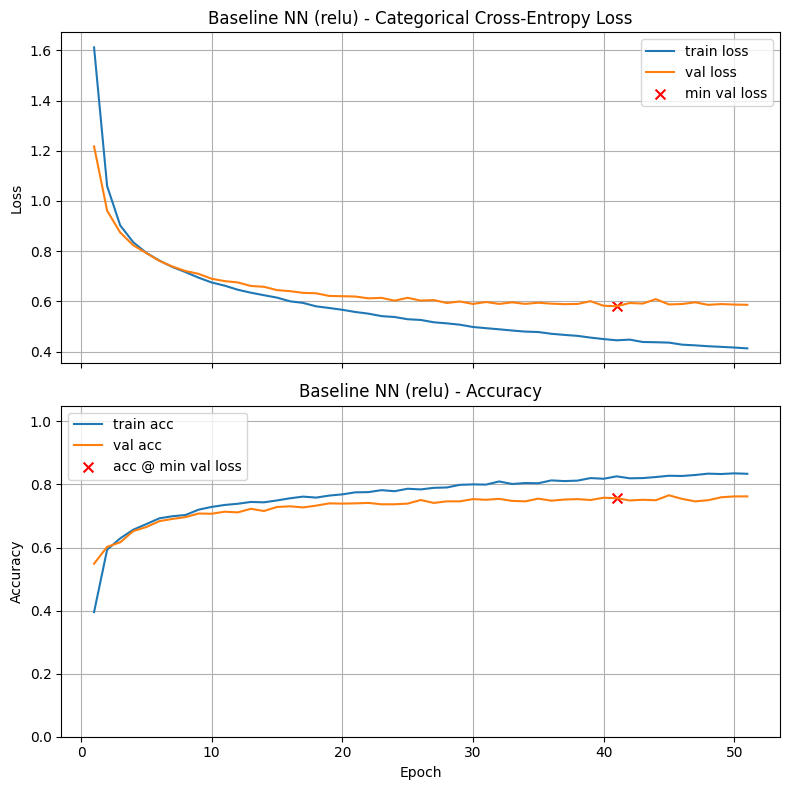

Final Training Loss:            0.4129
Final Training Accuracy:        0.8338
Final Validation Loss:          0.5864
Final Validation Accuracy:      0.7621
Minimum Validation Loss:        0.5809 (Epoch 41)
Validation Accuracy @ Min Loss: 0.7564

Test Loss: 0.5938
Test Accuracy: 0.7529

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:00:07
Training baseline model with activation = sigmoid

Baseline NN (sigmoid)



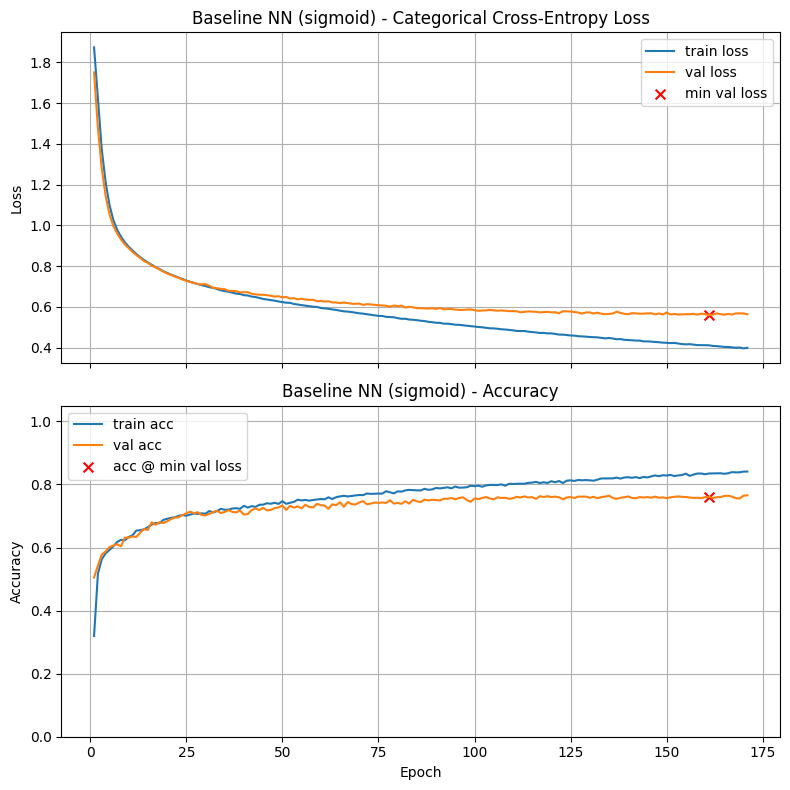

Final Training Loss:            0.3996
Final Training Accuracy:        0.8410
Final Validation Loss:          0.5639
Final Validation Accuracy:      0.7657
Minimum Validation Loss:        0.5599 (Epoch 161)
Validation Accuracy @ Min Loss: 0.7607

Test Loss: 0.5595
Test Accuracy: 0.7636

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:00:23
Training baseline model with activation = tanh

Baseline NN (tanh)



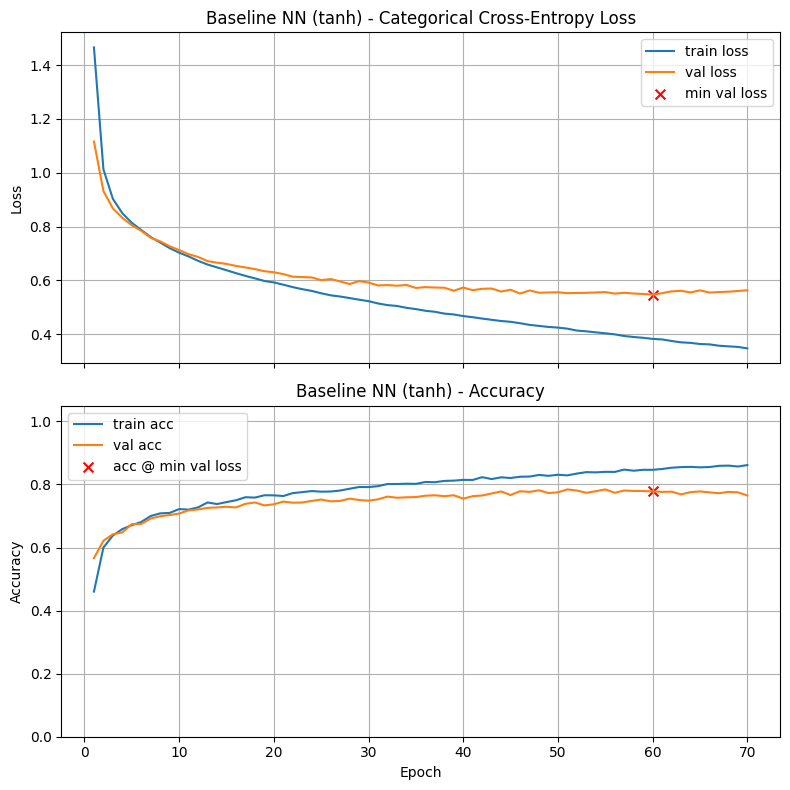

Final Training Loss:            0.3473
Final Training Accuracy:        0.8614
Final Validation Loss:          0.5633
Final Validation Accuracy:      0.7650
Minimum Validation Loss:        0.5473 (Epoch 60)
Validation Accuracy @ Min Loss: 0.7779

Test Loss: 0.5797
Test Accuracy: 0.7664

Validation-Test Gap (accuracy): 0.011429

Execution Time: 00:00:09

Validation Accuracy @ Minimum Validation Loss
Baseline NN (tanh)                      	0.7779
Baseline NN (sigmoid)                   	0.7607
Baseline NN (relu)                      	0.7564


In [9]:
# Your code here. Add as many cells as you need. 

activations = ['relu', 'sigmoid', 'tanh']

results.clear()  # clear results from previous runs
for act in activations:
    print("="*60)
    print(f"Training baseline model with activation = {act}")

    model_baseline = build_model(
        n_inputs=X_train.shape[1],
        layer_list=[
            (64, act, 0.0, 0.0),      # first hidden layer
            (32, act, 0.0, 0.0)     # second hidden layer
        ],
        n_classes=n_classes
    )

    train_and_test(
        model=model_baseline,
        title=f"Baseline NN ({act})",
        verbose=0
    )


print("\nValidation Accuracy @ Minimum Validation Loss")
print_results()



### Graded Questions

In [10]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 2             # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)

In [11]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 2


In [12]:
# Set a1b to the validation accuracy found by this best activation function

a1b = 0.7779            # Replace 0.0 with your answer

In [13]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7779


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**



Baseline Model (Tanh) | LR=1e-03



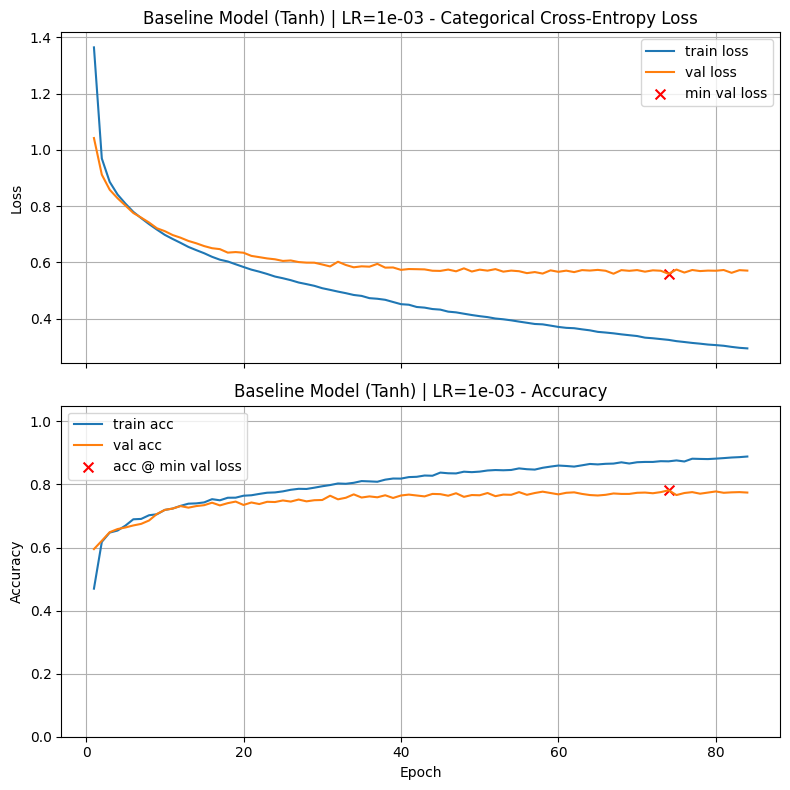

Final Training Loss:            0.2942
Final Training Accuracy:        0.8886
Final Validation Loss:          0.5706
Final Validation Accuracy:      0.7743
Minimum Validation Loss:        0.5589 (Epoch 74)
Validation Accuracy @ Min Loss: 0.7814

Test Loss: 0.5639
Test Accuracy: 0.7629

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:11

Baseline Model (Tanh) | LR=5e-04



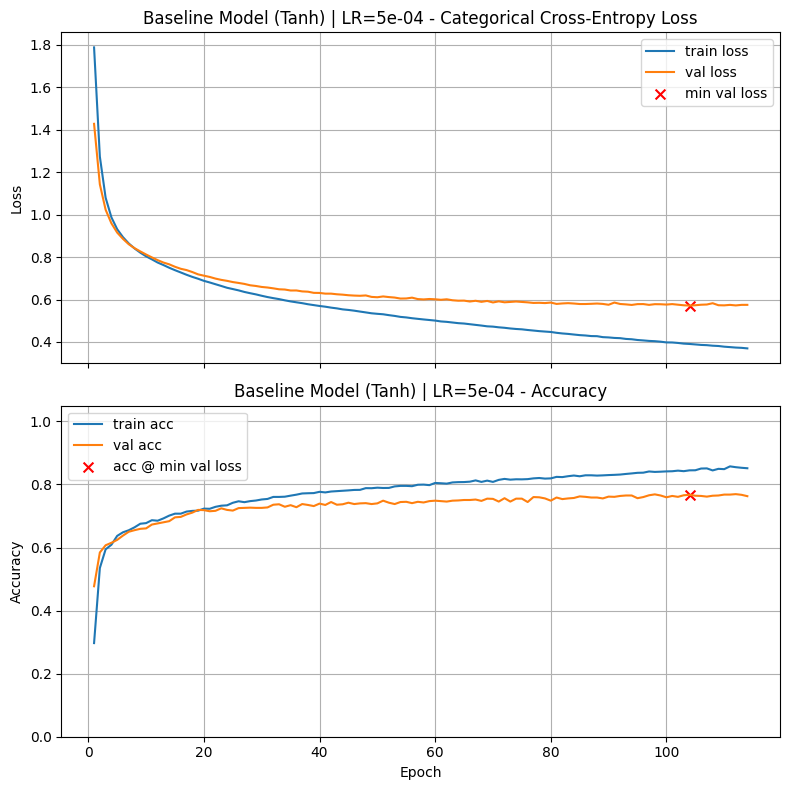

Final Training Loss:            0.3699
Final Training Accuracy:        0.8514
Final Validation Loss:          0.5748
Final Validation Accuracy:      0.7629
Minimum Validation Loss:        0.5714 (Epoch 104)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.5741
Test Accuracy: 0.7579

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:15

Baseline Model (Tanh) | LR=1e-04



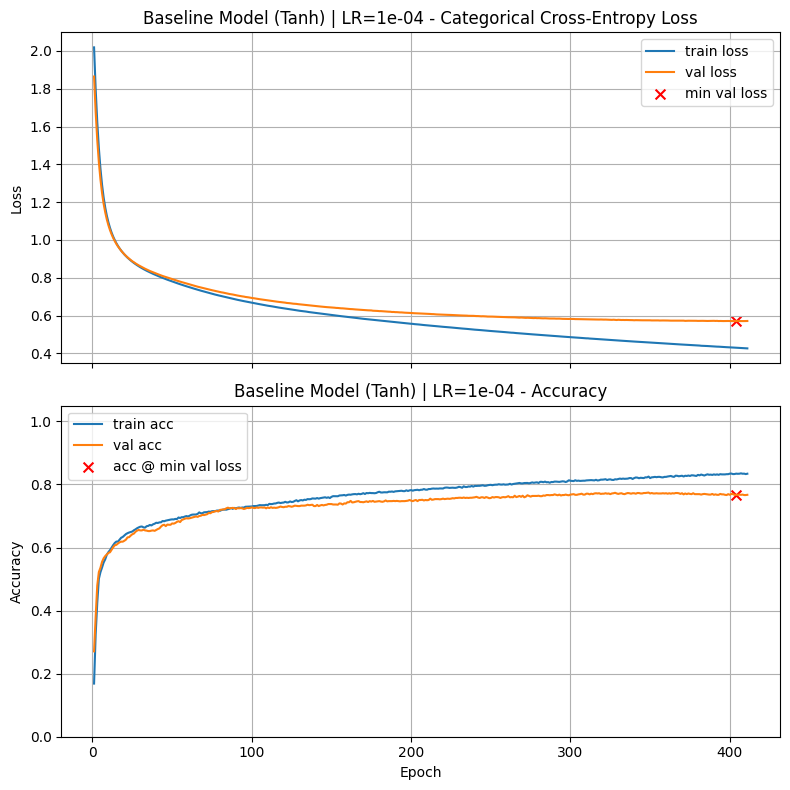

Final Training Loss:            0.4264
Final Training Accuracy:        0.8340
Final Validation Loss:          0.5713
Final Validation Accuracy:      0.7671
Minimum Validation Loss:        0.5705 (Epoch 404)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.5898
Test Accuracy: 0.7707

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:00:53

Baseline Model (Tanh) | LR=5e-05



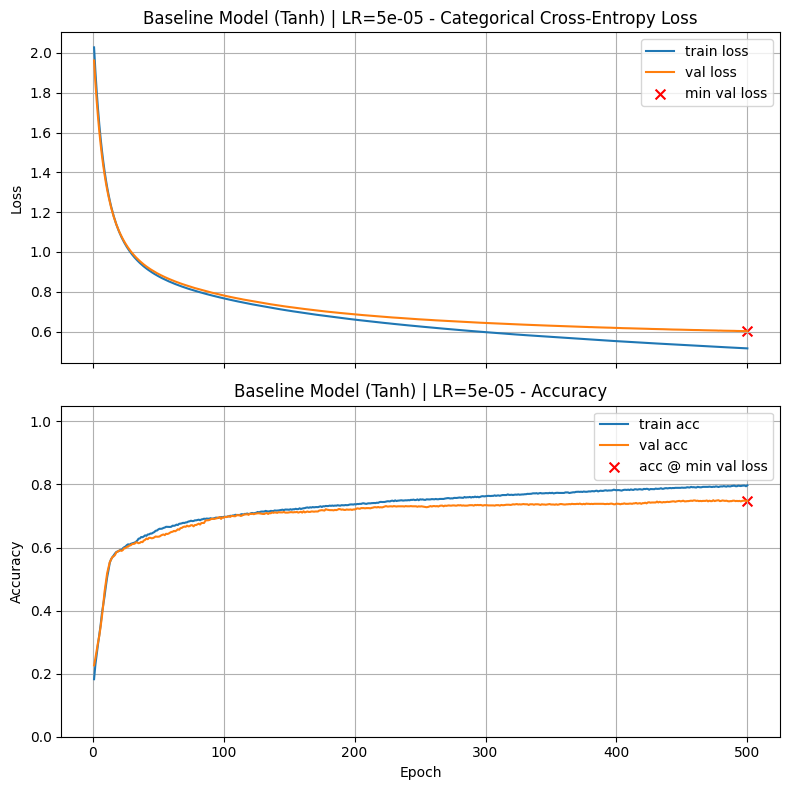

Final Training Loss:            0.5153
Final Training Accuracy:        0.7971
Final Validation Loss:          0.6019
Final Validation Accuracy:      0.7479
Minimum Validation Loss:        0.6019 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7479

Test Loss: 0.6194
Test Accuracy: 0.7464

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:01:04

Baseline Model (Tanh) | LR=1e-05



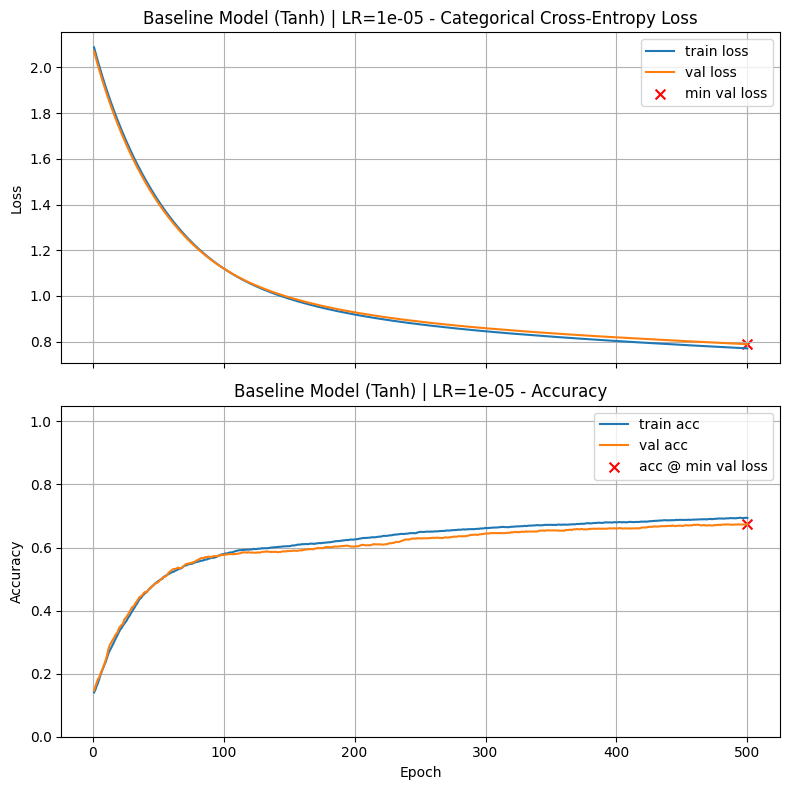

Final Training Loss:            0.7706
Final Training Accuracy:        0.6940
Final Validation Loss:          0.7890
Final Validation Accuracy:      0.6743
Minimum Validation Loss:        0.7890 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6743

Test Loss: 0.8013
Test Accuracy: 0.6893

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:01:02

=== Learning Rate Comparison (Best → Worst) ===
Baseline Model (Tanh) | LR=1e-03        	0.7814
Baseline NN (tanh)                      	0.7779
Baseline Model (Tanh) | LR=5e-04        	0.7671
Baseline Model (Tanh) | LR=1e-04        	0.7671
Baseline NN (sigmoid)                   	0.7607
Baseline NN (relu)                      	0.7564
Baseline Model (Tanh) | LR=5e-05        	0.7479
Baseline Model (Tanh) | LR=1e-05        	0.6743


In [14]:
# Your code here. Add as many cells as you need. 

learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]

# results.clear()  # clear results from previous runs
for lr in learning_rates:
    
    # IMPORTANT: rebuild a fresh model each time
    model = build_model(
        n_inputs=X_train.shape[1],
        layer_list=[
            (64, 'tanh', 0.0, 0.0),
            (32, 'tanh', 0.0, 0.0)
        ],
        n_classes=n_classes
    )
    
    title = f"Baseline Model (Tanh) | LR={lr:.0e}"
    
    train_and_test(
        model=model,
        epochs=500,
        lr_schedule=lr,
        optimizer="Adam",
        title=title,
        batch_size=64,
        use_early_stopping=True,
        patience=10,
        min_delta=1e-4,
        verbose=0
    )

# Print summary ranked by best validation accuracy @ min val loss
print("\n=== Learning Rate Comparison (Best → Worst) ===")
print_results()


#### Graded Questions

In [15]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 1e-03           # Replace 0.0 with your answer

In [16]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.6f}') 

a2a = 0.001000


In [17]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = 0.7814             # Replace 0.0 with your answer

In [18]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7814


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Dropout d1=0.0, d2=0.3



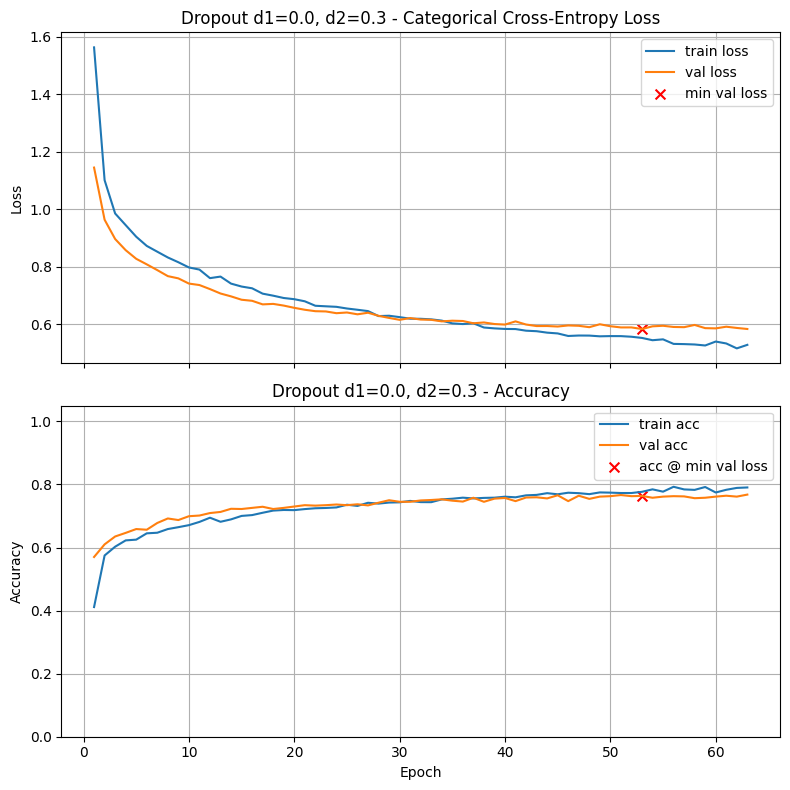

Final Training Loss:            0.5277
Final Training Accuracy:        0.7905
Final Validation Loss:          0.5829
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.5828 (Epoch 53)
Validation Accuracy @ Min Loss: 0.7636

Test Loss: 0.6139
Test Accuracy: 0.7514

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:00:08

Dropout d1=0.0, d2=0.4



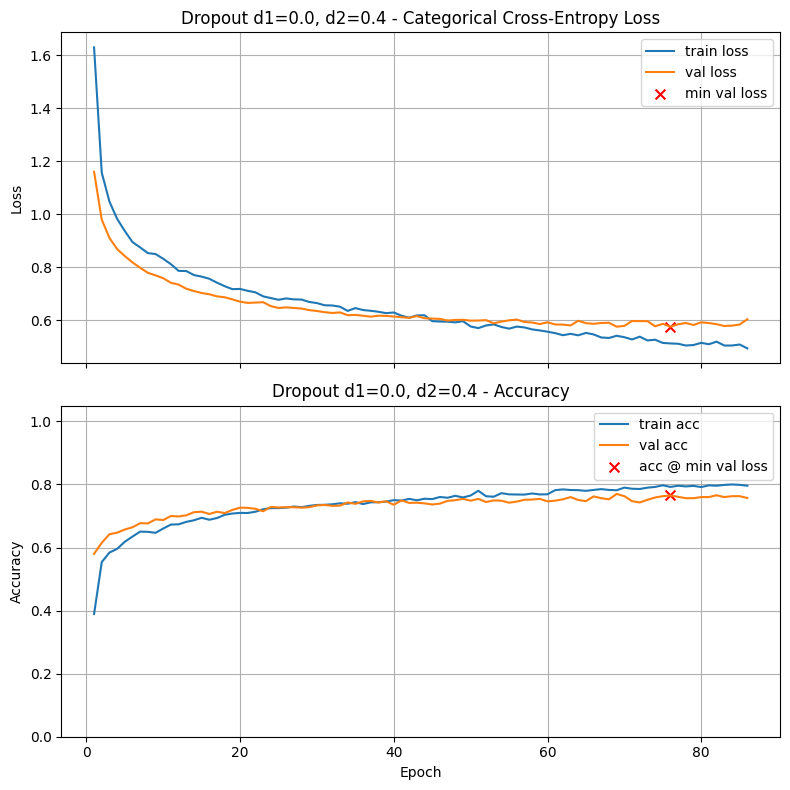

Final Training Loss:            0.4937
Final Training Accuracy:        0.7960
Final Validation Loss:          0.6036
Final Validation Accuracy:      0.7571
Minimum Validation Loss:        0.5754 (Epoch 76)
Validation Accuracy @ Min Loss: 0.7650

Test Loss: 0.6155
Test Accuracy: 0.7593

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:11

Dropout d1=0.0, d2=0.5



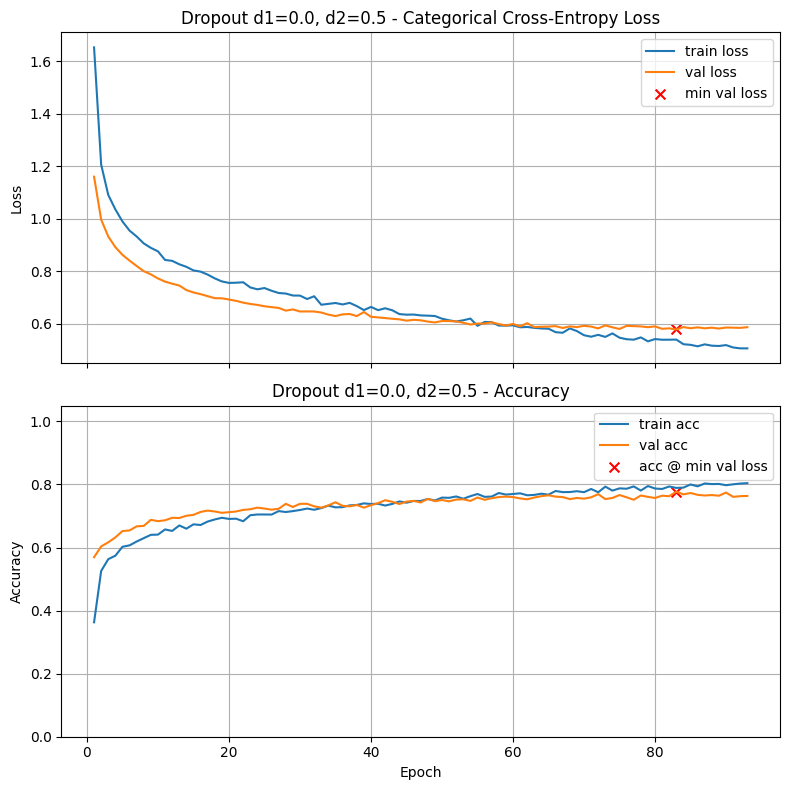

Final Training Loss:            0.5052
Final Training Accuracy:        0.8040
Final Validation Loss:          0.5860
Final Validation Accuracy:      0.7636
Minimum Validation Loss:        0.5772 (Epoch 83)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.6068
Test Accuracy: 0.7536

Validation-Test Gap (accuracy): 0.023571

Execution Time: 00:00:12

Dropout d1=0.1, d2=0.3



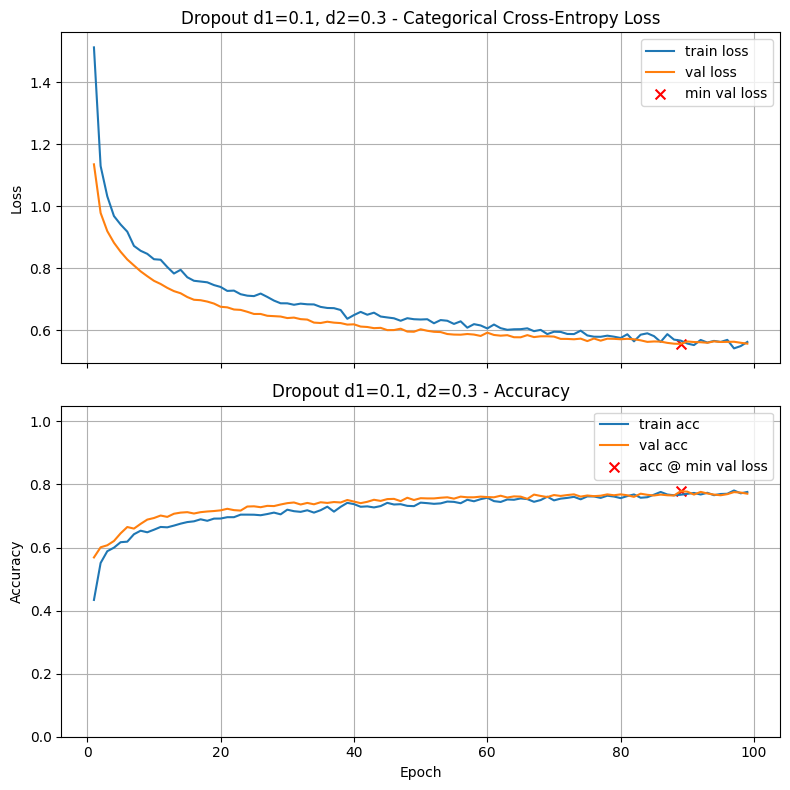

Final Training Loss:            0.5630
Final Training Accuracy:        0.7762
Final Validation Loss:          0.5575
Final Validation Accuracy:      0.7707
Minimum Validation Loss:        0.5567 (Epoch 89)
Validation Accuracy @ Min Loss: 0.7786

Test Loss: 0.5876
Test Accuracy: 0.7629

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:14

Dropout d1=0.1, d2=0.4



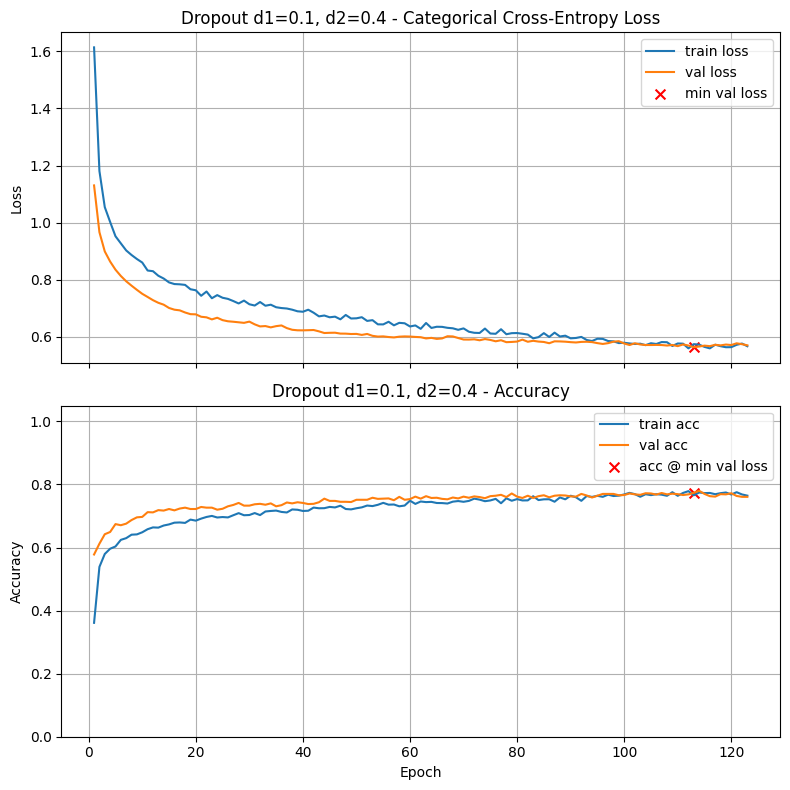

Final Training Loss:            0.5675
Final Training Accuracy:        0.7645
Final Validation Loss:          0.5707
Final Validation Accuracy:      0.7607
Minimum Validation Loss:        0.5641 (Epoch 113)
Validation Accuracy @ Min Loss: 0.7736

Test Loss: 0.5825
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:16

Dropout d1=0.1, d2=0.5



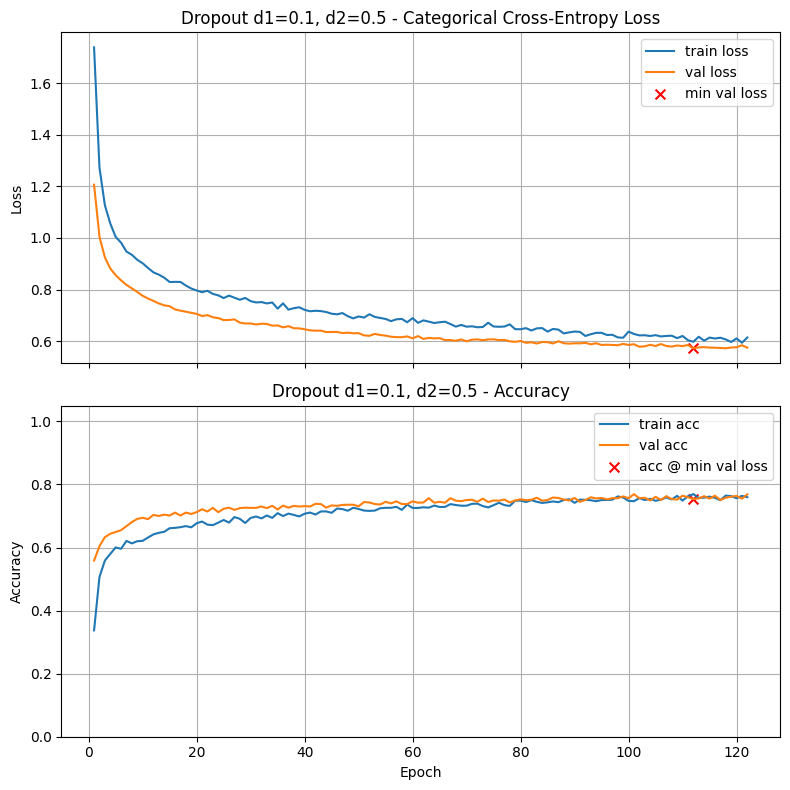

Final Training Loss:            0.6140
Final Training Accuracy:        0.7595
Final Validation Loss:          0.5746
Final Validation Accuracy:      0.7686
Minimum Validation Loss:        0.5719 (Epoch 112)
Validation Accuracy @ Min Loss: 0.7536

Test Loss: 0.6103
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.002143

Execution Time: 00:00:16

Dropout d1=0.2, d2=0.3



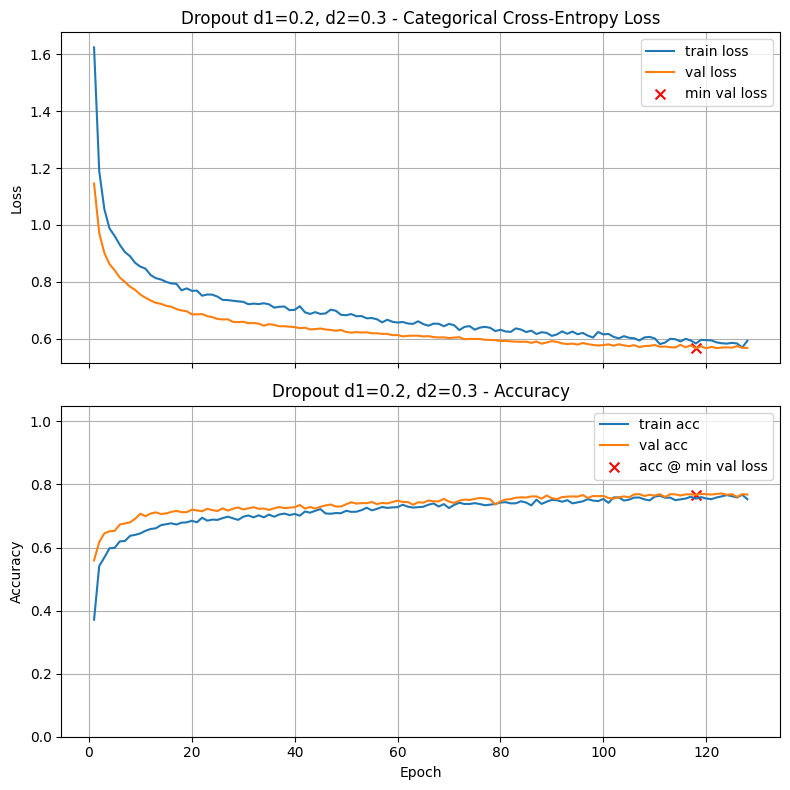

Final Training Loss:            0.5933
Final Training Accuracy:        0.7533
Final Validation Loss:          0.5683
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.5666 (Epoch 118)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.5976
Test Accuracy: 0.7500

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:17

Dropout d1=0.2, d2=0.4



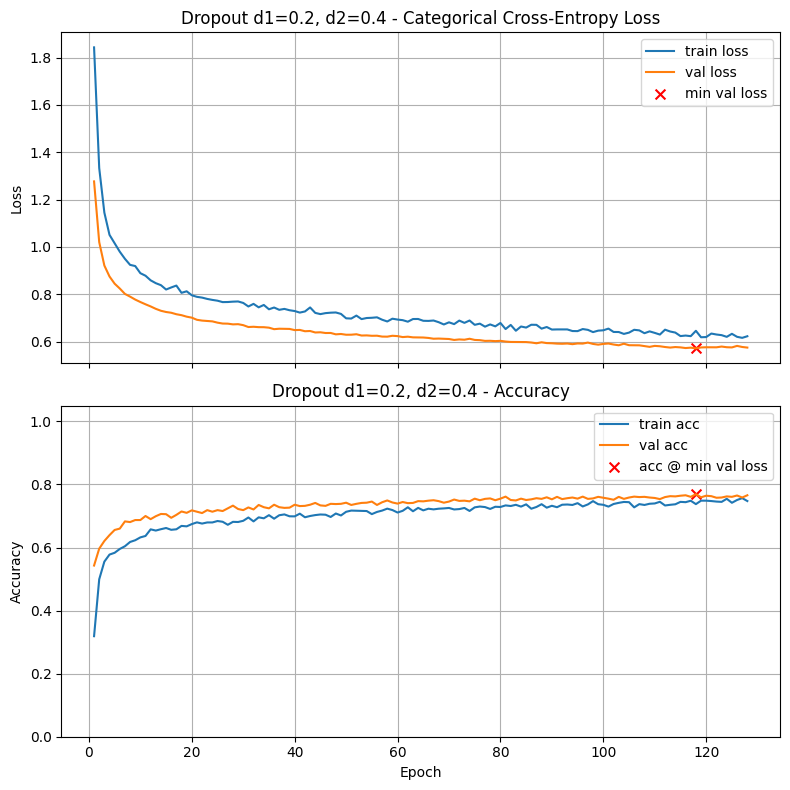

Final Training Loss:            0.6223
Final Training Accuracy:        0.7474
Final Validation Loss:          0.5744
Final Validation Accuracy:      0.7657
Minimum Validation Loss:        0.5710 (Epoch 118)
Validation Accuracy @ Min Loss: 0.7693

Test Loss: 0.6067
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:17

Dropout d1=0.2, d2=0.5



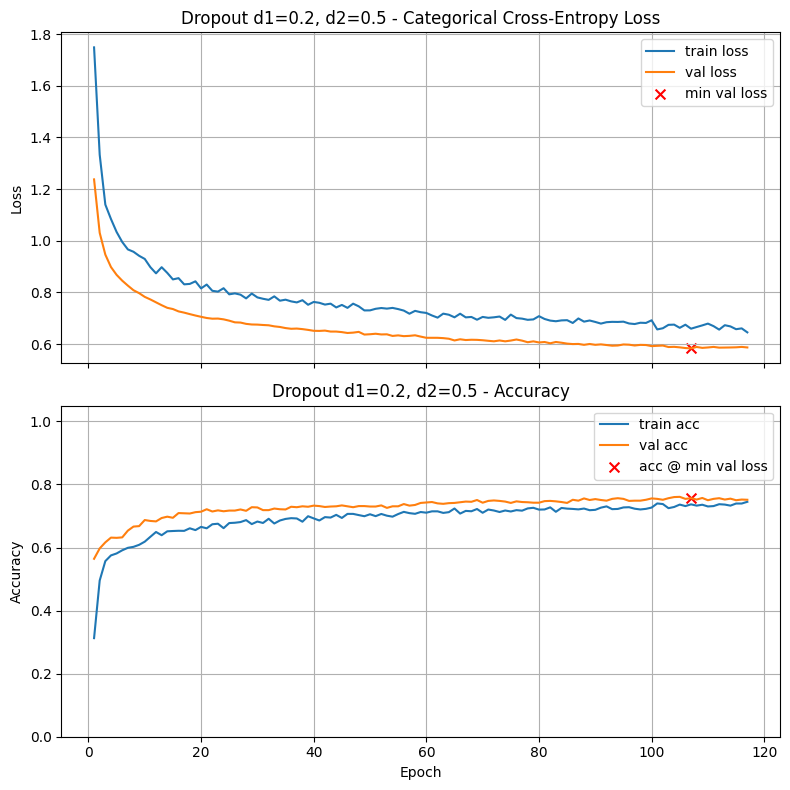

Final Training Loss:            0.6454
Final Training Accuracy:        0.7450
Final Validation Loss:          0.5869
Final Validation Accuracy:      0.7514
Minimum Validation Loss:        0.5833 (Epoch 107)
Validation Accuracy @ Min Loss: 0.7564

Test Loss: 0.6323
Test Accuracy: 0.7386

Validation-Test Gap (accuracy): 0.017857

Execution Time: 00:00:15

Problem 3 Results (Best → Worst)
Baseline Model (Tanh) | LR=1e-03        	0.7814
Dropout d1=0.1, d2=0.3                  	0.7786
Baseline NN (tanh)                      	0.7779
Dropout d1=0.0, d2=0.5                  	0.7771
Dropout d1=0.1, d2=0.4                  	0.7736
Dropout d1=0.2, d2=0.4                  	0.7693
Baseline Model (Tanh) | LR=5e-04        	0.7671
Baseline Model (Tanh) | LR=1e-04        	0.7671
Dropout d1=0.2, d2=0.3                  	0.7671
Dropout d1=0.0, d2=0.4                  	0.7650
Dropout d1=0.0, d2=0.3                  	0.7636
Baseline NN (sigmoid)                   	0.7607
Baseline NN (relu)                 

In [19]:
# Your code here. Add as many cells as you need. 

activation = 'tanh'
best_lr = 1e-03   # <-- replace with your Problem Two result

# results.clear()  # clear results from previous runs

dropout_first  = [0.0, 0.1, 0.2]
dropout_second = [0.3, 0.4, 0.5]

for d1 in dropout_first:
    for d2 in dropout_second:
        title = f"Dropout d1={d1}, d2={d2}"

        model = build_model(
            n_inputs=X_train.shape[1],
            layer_list=[
                (64, activation, 0.0, d1),
                (32, activation, 0.0, d2)
            ],
            n_classes=n_classes
        )

        train_and_test(
            model=model,
            lr_schedule=best_lr,
            title=title,
            verbose=0
        )

print("\nProblem 3 Results (Best → Worst)")
print_results()


In [20]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a3a = (0.1,0.3)             # Replace (0.0,0.0) with your answer

In [21]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 

a3a = (0.1, 0.3)


In [22]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = 0.7786             # Replace 0.0 with your answer

In [23]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7786


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simple by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



L2 both layers λ=0.0001



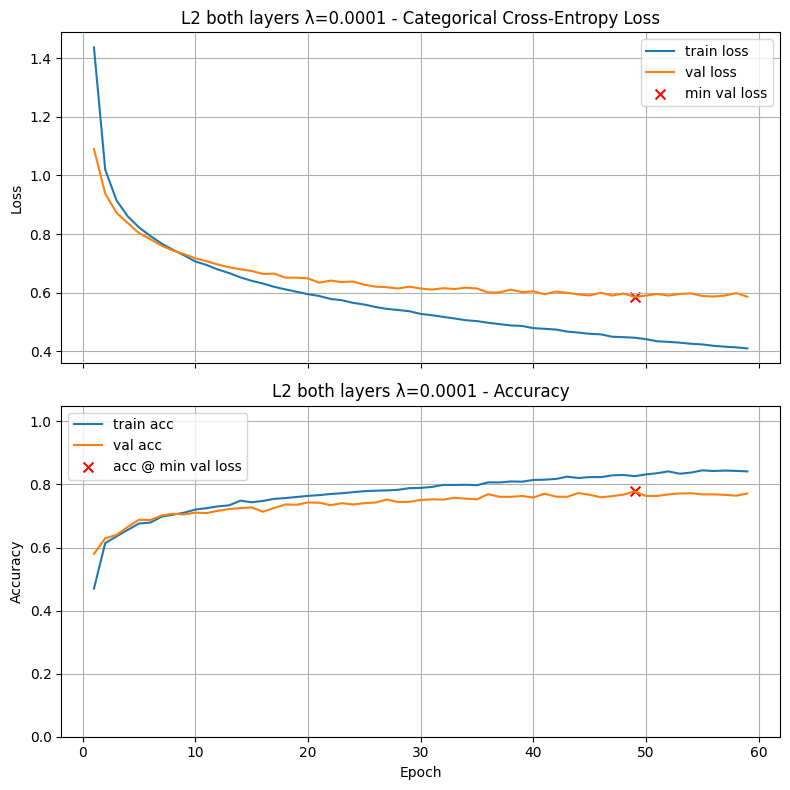

Final Training Loss:            0.4100
Final Training Accuracy:        0.8414
Final Validation Loss:          0.5862
Final Validation Accuracy:      0.7714
Minimum Validation Loss:        0.5855 (Epoch 49)
Validation Accuracy @ Min Loss: 0.7779

Test Loss: 0.6055
Test Accuracy: 0.7600

Validation-Test Gap (accuracy): 0.017857

Execution Time: 00:00:08

L2 both layers λ=0.001



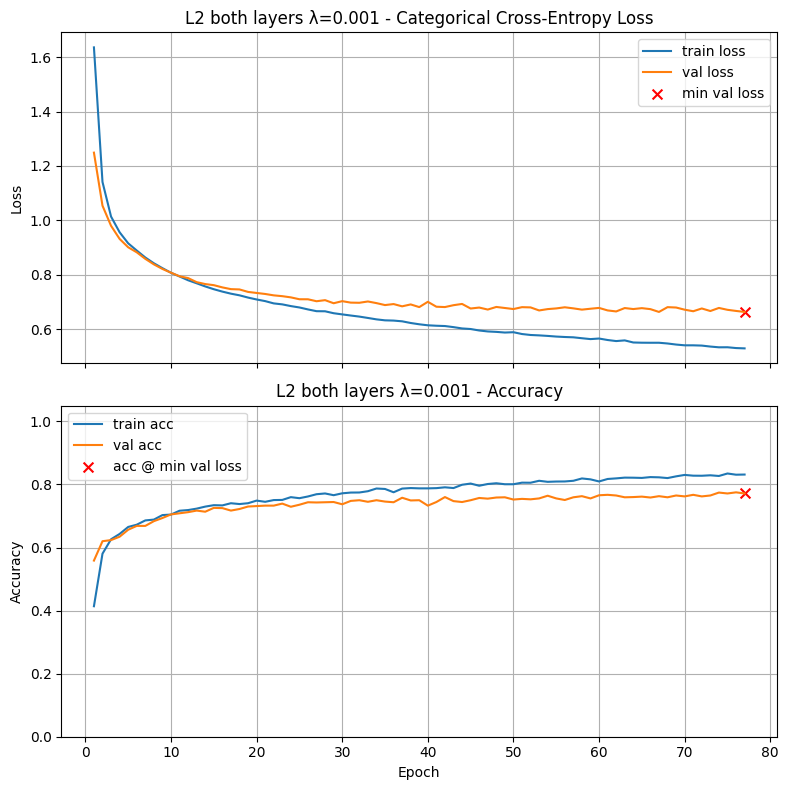

Final Training Loss:            0.5297
Final Training Accuracy:        0.8314
Final Validation Loss:          0.6635
Final Validation Accuracy:      0.7714
Minimum Validation Loss:        0.6635 (Epoch 77)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6665
Test Accuracy: 0.7629

Validation-Test Gap (accuracy): 0.000000

Execution Time: 00:00:10

L2 both layers λ=0.01



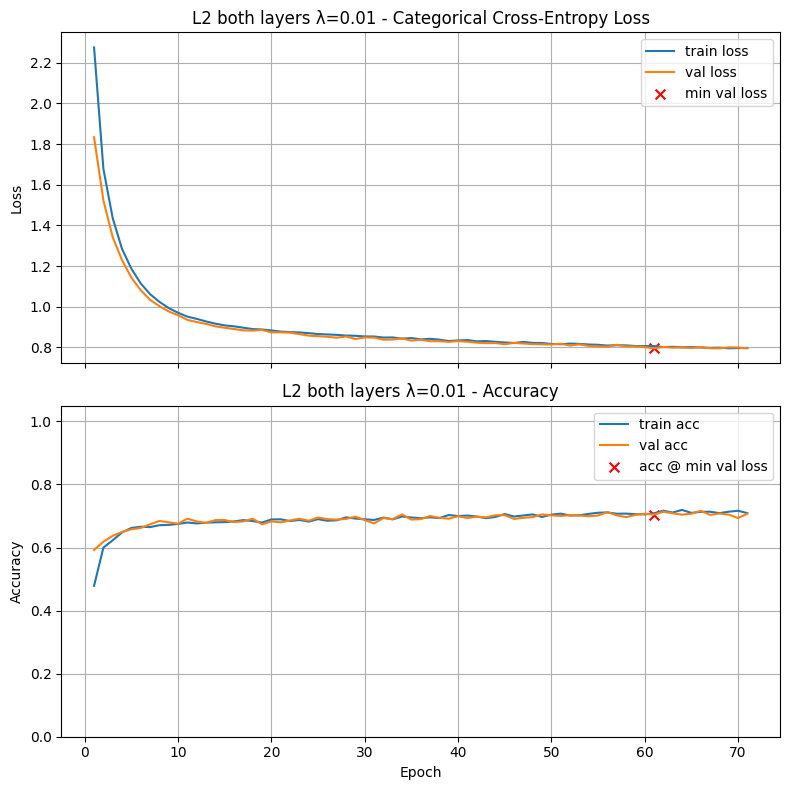

Final Training Loss:            0.7972
Final Training Accuracy:        0.7090
Final Validation Loss:          0.7952
Final Validation Accuracy:      0.7071
Minimum Validation Loss:        0.7950 (Epoch 61)
Validation Accuracy @ Min Loss: 0.7043

Test Loss: 0.8282
Test Accuracy: 0.6936

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:09

L2 λ1=1e-4, λ2=1e-3



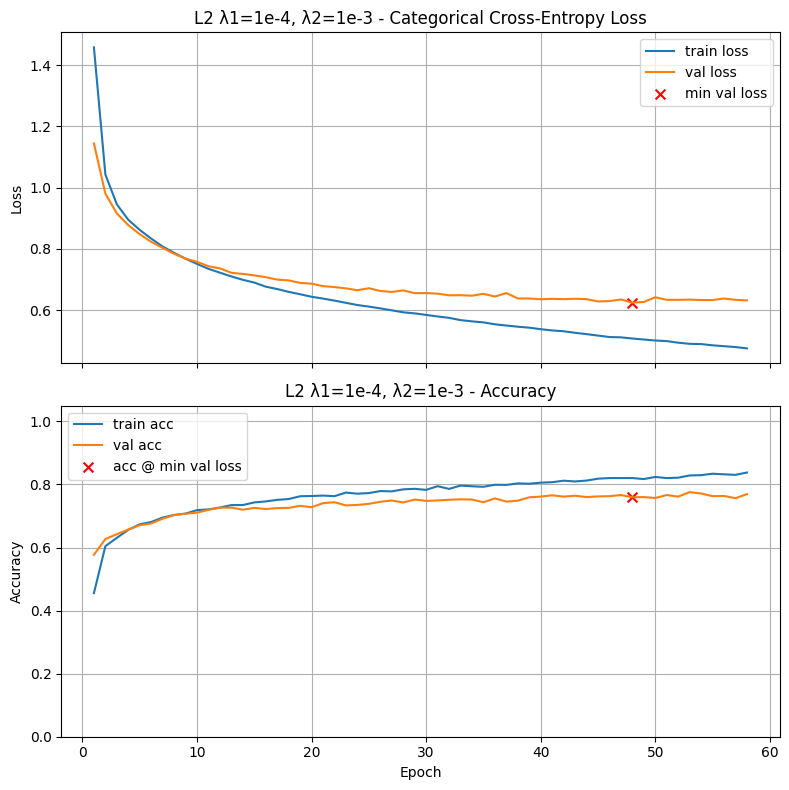

Final Training Loss:            0.4749
Final Training Accuracy:        0.8379
Final Validation Loss:          0.6315
Final Validation Accuracy:      0.7693
Minimum Validation Loss:        0.6241 (Epoch 48)
Validation Accuracy @ Min Loss: 0.7593

Test Loss: 0.6425
Test Accuracy: 0.7443

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:00:08

Problem 4 Results (Best → Worst)
Baseline Model (Tanh) | LR=1e-03        	0.7814
Dropout d1=0.1, d2=0.3                  	0.7786
Baseline NN (tanh)                      	0.7779
L2 both layers λ=0.0001                 	0.7779
Dropout d1=0.0, d2=0.5                  	0.7771
Dropout d1=0.1, d2=0.4                  	0.7736
L2 both layers λ=0.001                  	0.7714
Dropout d1=0.2, d2=0.4                  	0.7693
Baseline Model (Tanh) | LR=5e-04        	0.7671
Baseline Model (Tanh) | LR=1e-04        	0.7671
Dropout d1=0.2, d2=0.3                  	0.7671
Dropout d1=0.0, d2=0.4                  	0.7650
Dropout d1=0.0, d2=0.3              

In [24]:
# Your code here. Add as many cells as you need. 

# results.clear()  # clear results from previous runs
lambdas = [1e-4, 1e-3, 1e-2]

# same λ in both layers
for lam in lambdas:
    title = f"L2 both layers λ={lam}"

    model = build_model(
        n_inputs=X_train.shape[1],
        layer_list=[
            (64, activation, lam, 0.0),
            (32, activation, lam, 0.0)
        ],
        n_classes=n_classes
    )

    train_and_test(
        model=model,
        lr_schedule=best_lr,
        title=title,
        verbose=0
    )

# asymmetric λ
title = "L2 λ1=1e-4, λ2=1e-3"
model = build_model(
    n_inputs=X_train.shape[1],
    layer_list=[
        (64, activation, 1e-4, 0.0),
        (32, activation, 1e-3, 0.0)
    ],
    n_classes=n_classes
)

train_and_test(
    model=model,
    lr_schedule=best_lr,
    title=title,
    verbose=0
)

print("\nProblem 4 Results (Best → Worst)")
print_results()


In [25]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a4a = (0.0001,0.0001)             # Replace (0.0,0.0) with your answer

In [26]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a}') 

a4a = (0.0001, 0.0001)


In [27]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = 0.7779             # Replace 0.0 with your answer

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.7779


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari 
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.




Dropout (0.1,0.3) + L2=0.0001



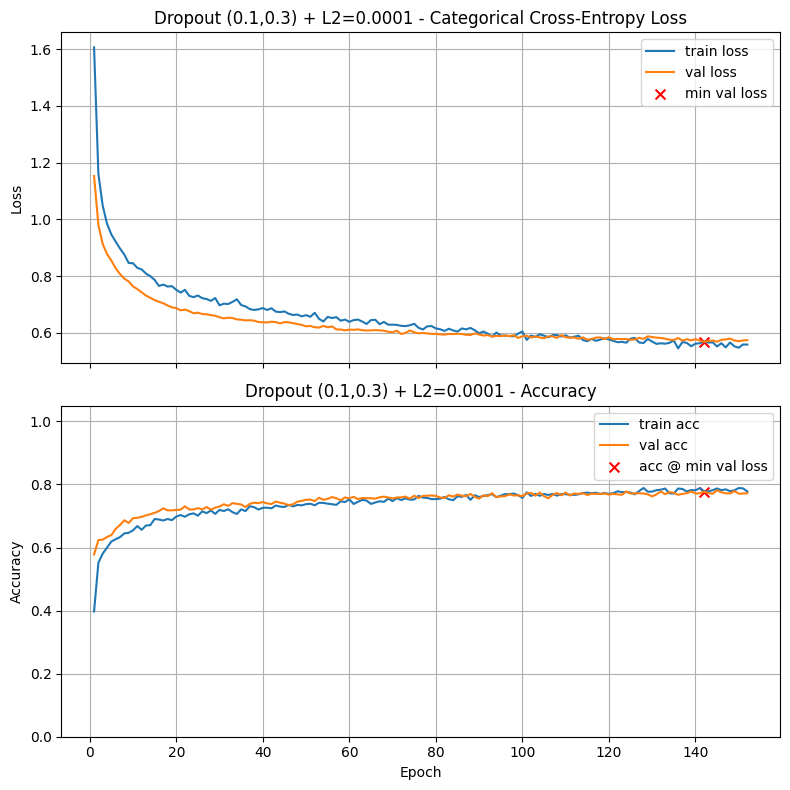

Final Training Loss:            0.5580
Final Training Accuracy:        0.7776
Final Validation Loss:          0.5738
Final Validation Accuracy:      0.7721
Minimum Validation Loss:        0.5676 (Epoch 142)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.6146
Test Accuracy: 0.7600

Validation-Test Gap (accuracy): 0.017143

Execution Time: 00:00:20

Dropout (0.1,0.3) + L2=0.001



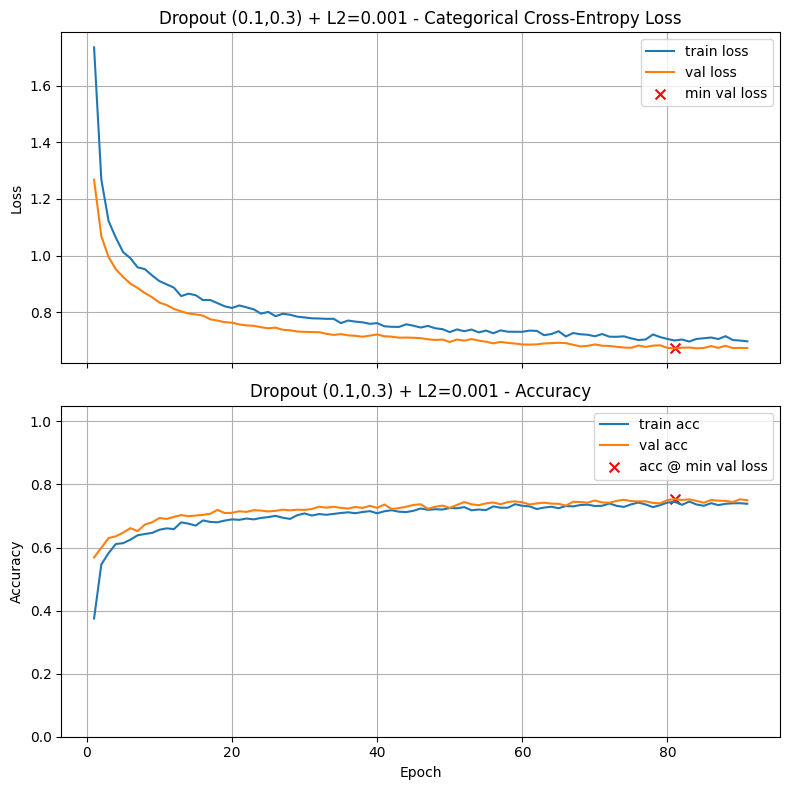

Final Training Loss:            0.6979
Final Training Accuracy:        0.7388
Final Validation Loss:          0.6739
Final Validation Accuracy:      0.7500
Minimum Validation Loss:        0.6730 (Epoch 81)
Validation Accuracy @ Min Loss: 0.7536

Test Loss: 0.7089
Test Accuracy: 0.7336

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:12

Dropout (0.1,0.3) + L2=0.01



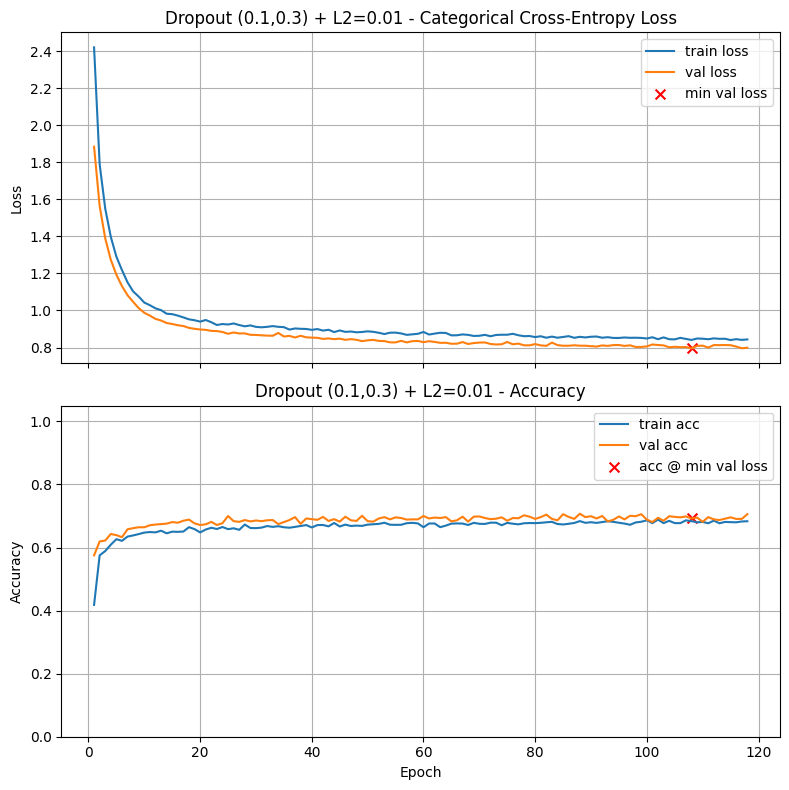

Final Training Loss:            0.8436
Final Training Accuracy:        0.6833
Final Validation Loss:          0.7990
Final Validation Accuracy:      0.7057
Minimum Validation Loss:        0.7953 (Epoch 108)
Validation Accuracy @ Min Loss: 0.6921

Test Loss: 0.8195
Test Accuracy: 0.6971

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:00:16

Reduced Dropout (0.0,0.3) + L2=1e-3



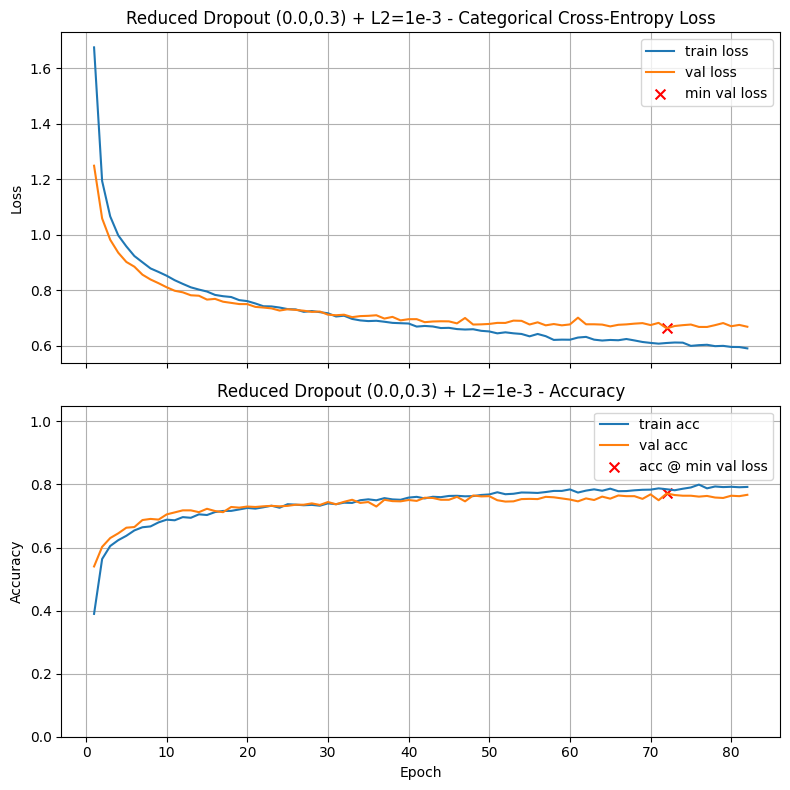

Final Training Loss:            0.5912
Final Training Accuracy:        0.7921
Final Validation Loss:          0.6691
Final Validation Accuracy:      0.7671
Minimum Validation Loss:        0.6634 (Epoch 72)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6939
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.019286

Execution Time: 00:00:11

Problem 5 Results (Best → Worst)
Dropout (0.1,0.3) + L2=0.0001           	0.7771
Reduced Dropout (0.0,0.3) + L2=1e-3     	0.7714
Dropout (0.1,0.3) + L2=0.001            	0.7536
Dropout (0.1,0.3) + L2=0.01             	0.6921


In [29]:
# Your code here. Add as many cells as you need.


# Replace with your Problem Three winner
best_d1 = 0.1
best_d2 = 0.3

lambdas = [1e-4, 1e-3, 1e-2]

results.clear()  # clear results from previous runs

# fixed dropout + L2
for lam in lambdas:
    title = f"Dropout ({best_d1},{best_d2}) + L2={lam}"

    model = build_model(
        n_inputs=X_train.shape[1],
        layer_list=[
            (64, activation, lam, best_d1),
            (32, activation, lam, best_d2)
        ],
        n_classes=n_classes
    )

    train_and_test(
        model=model,
        lr_schedule=best_lr,
        title=title,
        verbose=0
    )

# reduced dropout + L2
title = "Reduced Dropout (0.0,0.3) + L2=1e-3"
model = build_model(
    n_inputs=X_train.shape[1],
    layer_list=[
        (64, activation, 1e-3, 0.0),
        (32, activation, 1e-3, 0.2)
    ],
    n_classes=n_classes
)

train_and_test(
    model=model,
    lr_schedule=best_lr,
    title=title,
    verbose=0
)

print("\nProblem 5 Results (Best → Worst)")
print_results()


In [30]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = 0.7771             # Replace 0.0 with your answer

In [31]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5 = {a5:.4f}') 

a5 = 0.7771


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.



Best Model (TanH + Dropout (0.1,0.3) + L2=0.0001+0.001 + LR Decay 132 steps, 0.92 rate batch size 32)



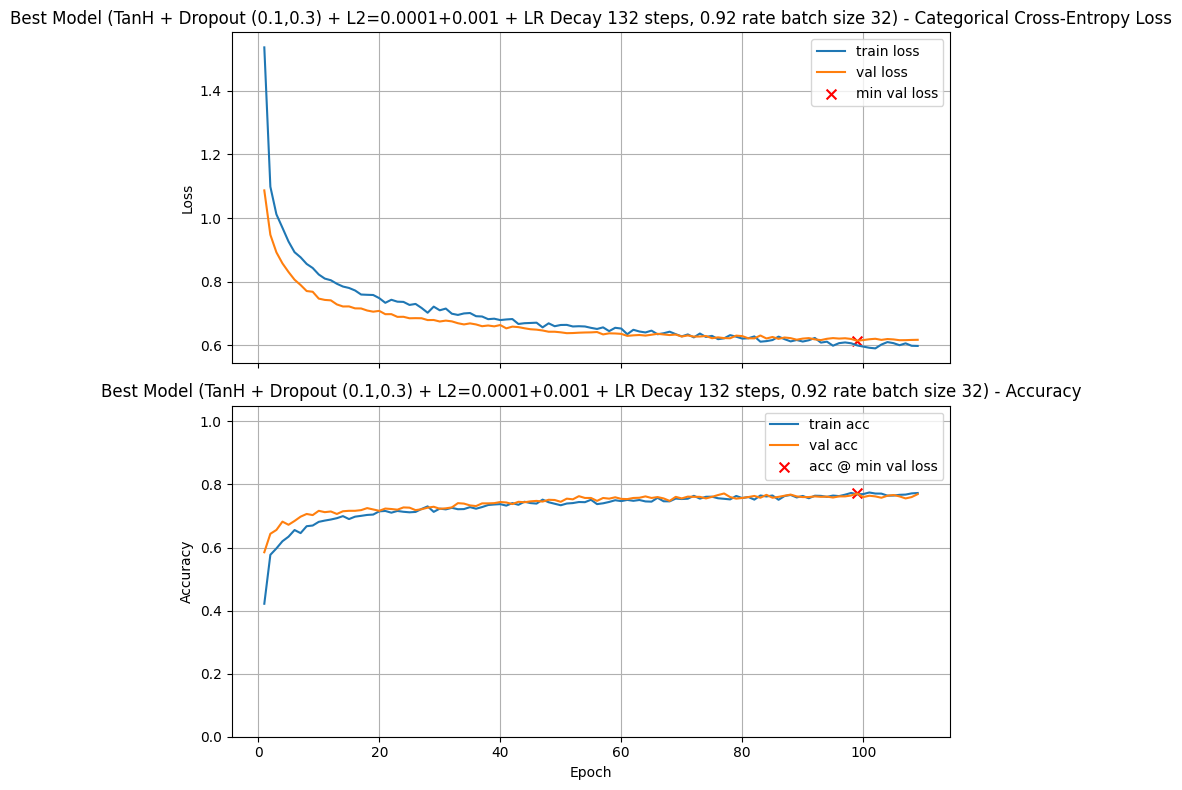

Final Training Loss:            0.5977
Final Training Accuracy:        0.7729
Final Validation Loss:          0.6169
Final Validation Accuracy:      0.7693
Minimum Validation Loss:        0.6140 (Epoch 99)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6414
Test Accuracy: 0.7514

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:22


In [45]:
# Your code here


decay_rate = 0.92
lamb1 = 1e-4
lamb2 = 1e-3
dropout_first  = 0.1
dropout_second = 0.3
batch_size = 32
nodes1 = 64
nodes2 = 32
decay_steps = int(np.ceil(len(X_train) / batch_size))

title = f"Best Model (TanH + Dropout ({dropout_first},{dropout_second}) + L2={lamb1}+{lamb2} + LR Decay {decay_steps} steps, {decay_rate} rate batch size {batch_size})"

lr_schedule = ExponentialDecay(
    initial_learning_rate=best_lr,
    decay_steps=decay_steps * 10,
    decay_rate=decay_rate,
    staircase=True
)

best_model = build_model(
    n_inputs=X_train.shape[1],
    layer_list=[
        (nodes1, activation, lamb1, dropout_first),
        (nodes2, activation, lamb2, dropout_second)
    ],
    n_classes=n_classes
)

train_and_test(
    model=best_model,
    lr_schedule=lr_schedule,
    batch_size=batch_size,
    title=title,
    verbose=0
)


In [46]:
# Set a6 to the validation accuracy found by this best model

a6 = 0.7714            # Replace 0.0 with your answer

In [47]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a6 = {a6:.4f}') 

a6 = 0.7714


### Optional: Print out your results of all experiments

In [48]:
print_results()

Dropout (0.1,0.3) + L2=0.0001           	0.7771
Reduced Dropout (0.0,0.3) + L2=1e-3     	0.7714
Best Model (TanH + Dropout (0.1,0.3) + L2=0.0001+0.001 + LR Decay 132 steps, 0.92 rate batch size 32)	0.7714
Best Model (TanH + Dropout (0.1,0.3) + L2=0.0001+0.001 + LR Decay 33 steps, 0.98 rate batch size 128)	0.7707
Best Model (TanH + Dropout (0.1,0.3) + L2=0.0001+0.001 + LR Decay 132 steps, 0.95 rate batch size 32)	0.7679
Best Model (TanH + Dropout (0.1,0.3) + L2=0.0001+0.001 + LR Decay 132 steps, 0.98 rate batch size 32)	0.7664
Best Model (TanH + Dropout (0.2,0.4) + L2=0.0001+0.001 + LR Decay 33 steps, 0.98 rate batch size 128)	0.7543
Dropout (0.1,0.3) + L2=0.001            	0.7536
Best Model (TanH + Dropout (0.1,0.3) + L2=0.001+0.001 + LR Decay 66 steps, 0.95 rate batch size 64)	0.7436
Best Model (TanH + Dropout (0.1,0.3) + L2=0.01+0.01 + LR Decay 132 steps, 0.92 rate batch size 32)	0.7029
Dropout (0.1,0.3) + L2=0.01             	0.6921


## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these. 

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?